In [3]:

import src.utils as utils
pix4d_ndvi_path = '/raid/biplab/souravr/TIH/CROP/test_region_ndvi/R1T2_VIs.tif'
pix4D_ndvi_data, _, _, _ = utils.load_tif_numpy_with_meta(pix4d_ndvi_path)
print(pix4D_ndvi_data.shape)

(1, 166, 418)


In [5]:
my_ndvi_path = '/raid/biplab/souravr/TIH/CROP/outputs/regions/28Aug23/R1T2_VIs.tif'
my_all_data, _, _, _ = utils.load_tif_numpy_with_meta(my_ndvi_path)
my_ndvi_data = my_all_data[0]  # Assuming NDVI is the 4th band
print(my_ndvi_data.shape)

(166, 418)


In [7]:
pix4D_ndvi_data = pix4D_ndvi_data[0]
print(pix4D_ndvi_data.shape)

(166, 418)


In [ ]:
residual = my_ndvi_data - pix4D_ndvi_data

print(residual.sum())

19417.36115394324


In [30]:
def plot_residuals(residual, title):
    import matplotlib.pyplot as plt

    # Compute the sum of residuals for each row
    row_residuals = residual.sum(axis=1)
    row_residuals[(row_residuals > 100) | (row_residuals < -100)] = 0  # Replace invalid values with 0
    # Plot the histogram of the row-wise residuals
    plt.plot(row_residuals, marker='o', linestyle='-')
    plt.xlabel("Row index")
    plt.ylabel("Residual sum")
    plt.title(f"Row Residuals per Row: {title}")
    plt.show()

In [17]:
my_ndvi_data = utils.clean_tif(my_ndvi_data)
pix4D_ndvi_data = utils.clean_tif(pix4D_ndvi_data)

Percentage of NaN values: 62.15%
Percentage of NaN values: 62.15%


In [47]:
def plot_compare_hist(my_ndvi_data, label1, pix4d_ndvi_data, label2, title):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.hist(my_ndvi_data.flatten(), bins=50, color='green', edgecolor='black', label=label1, alpha=0.5, range=(-1, 1))
    plt.hist(pix4d_ndvi_data.flatten(), bins=50, color='red', edgecolor='black', label=label2, alpha=0.5, range=(-1, 1))
    plt.xlim(-1, 1)
    plt.xlabel("Pixel Value")
    plt.ylabel("Count")
    plt.title(f"Histogram of Pixel Values: {title}")
    plt.legend()
    plt.show()

In [36]:
def plot_heatmap(residual):
    plt.figure(figsize=(12, 8))
    plt.imshow(residual, cmap='RdBu_r', vmin=-2, vmax=2)
    plt.colorbar(label='Residual Values')
    plt.title('Heatmap of Residuals (My NDVI - Pix4D NDVI)')
    plt.xlabel('Column Index')
    plt.ylabel('Row Index')
    plt.show()  

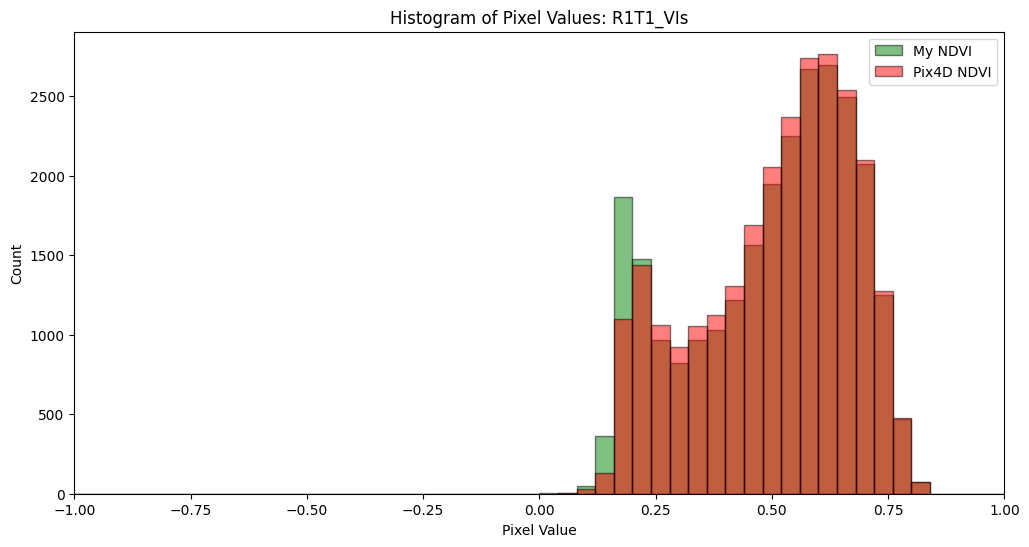

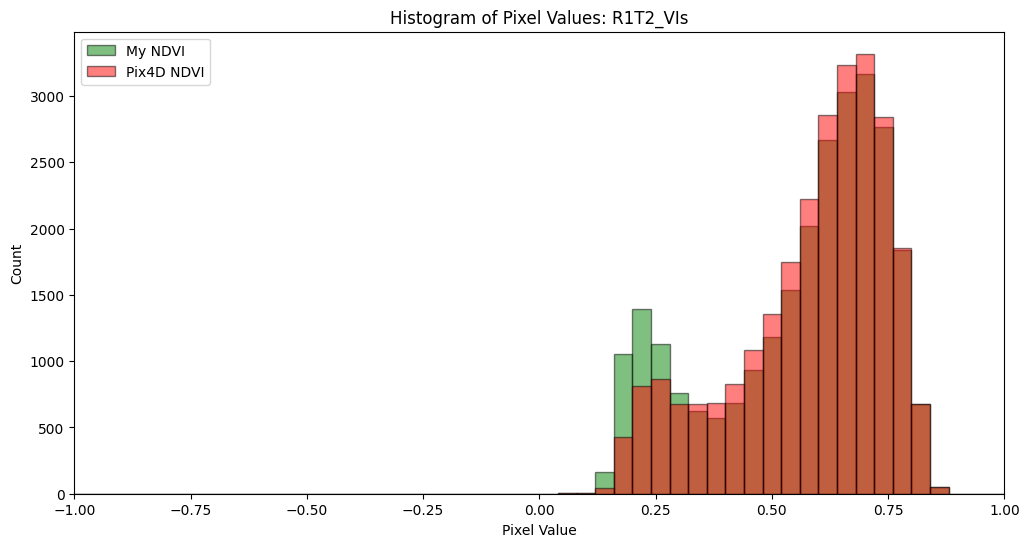

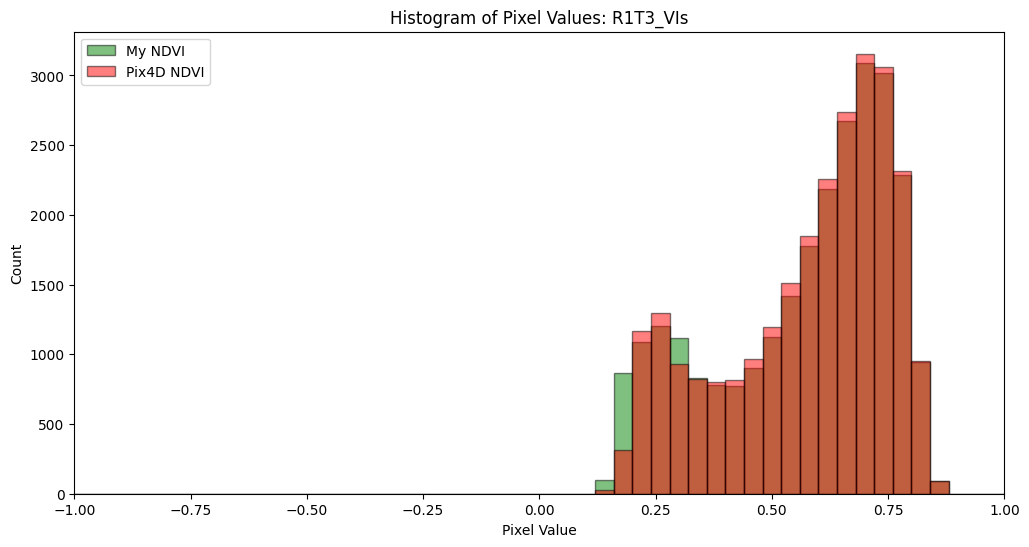

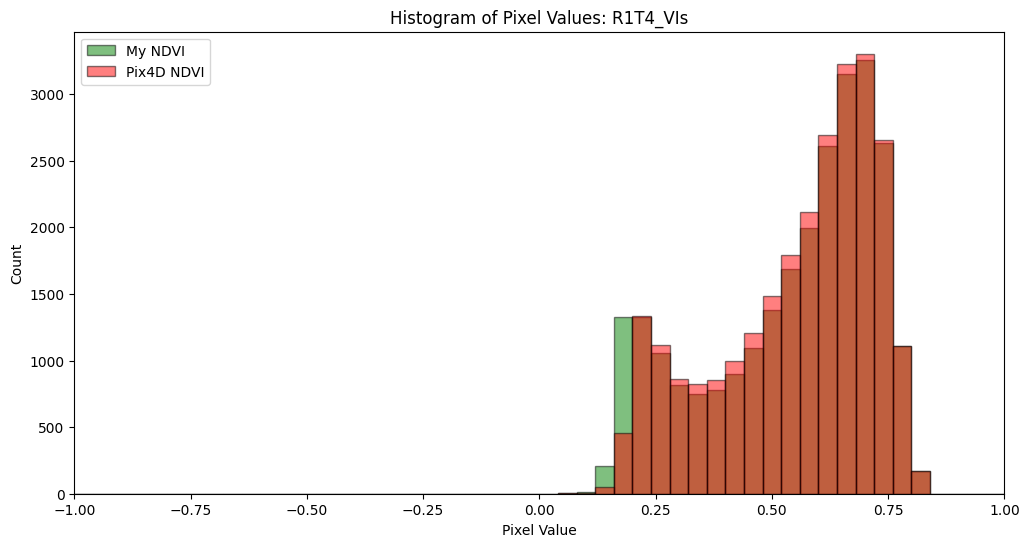

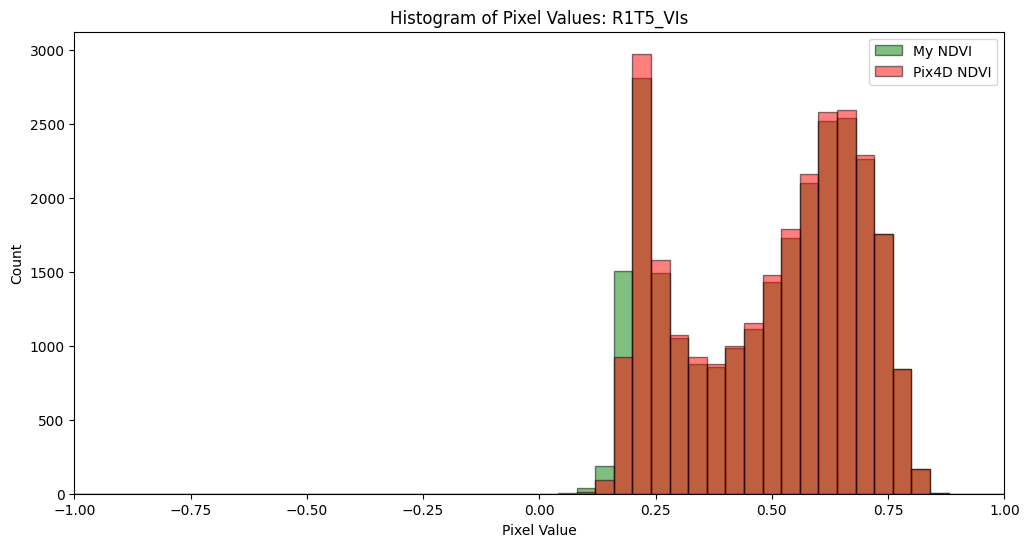

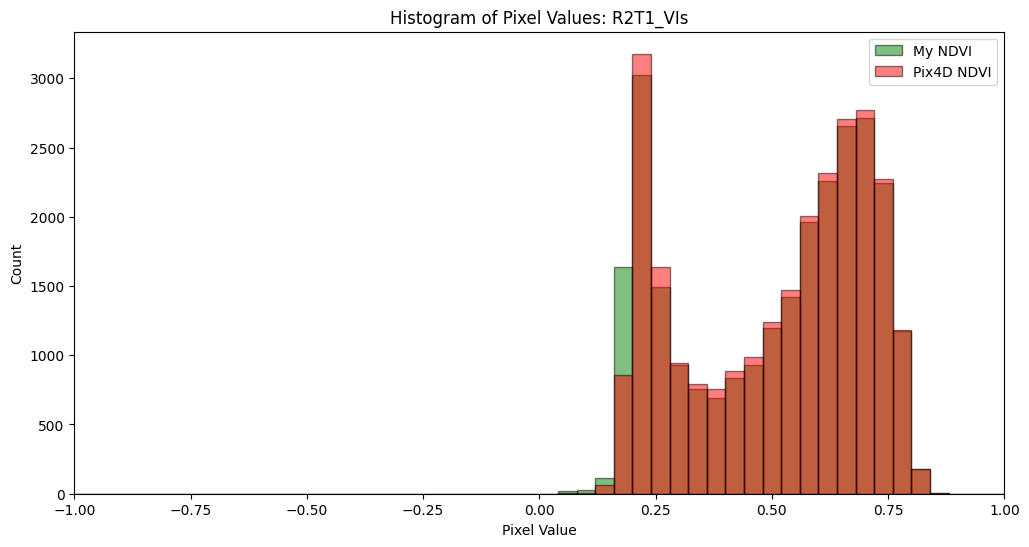

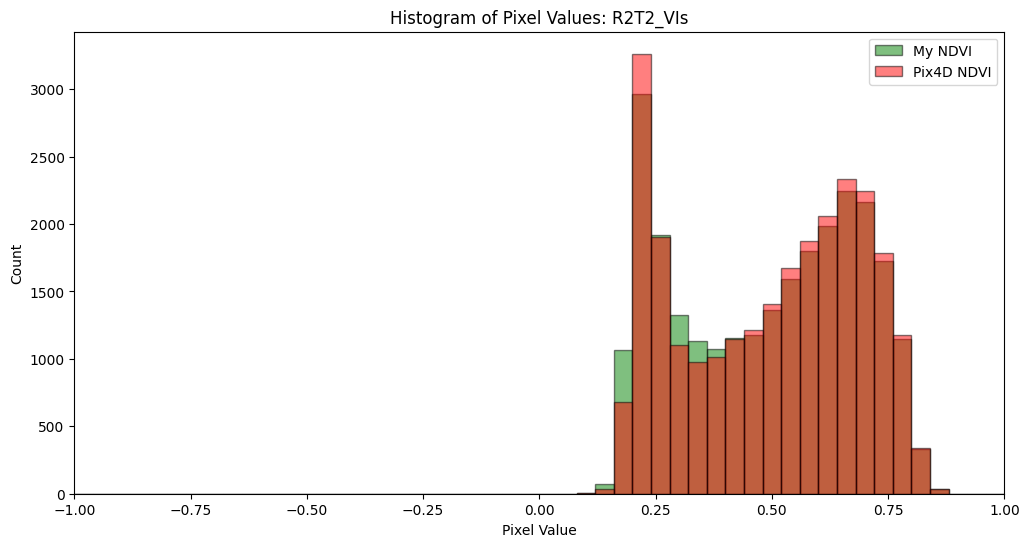

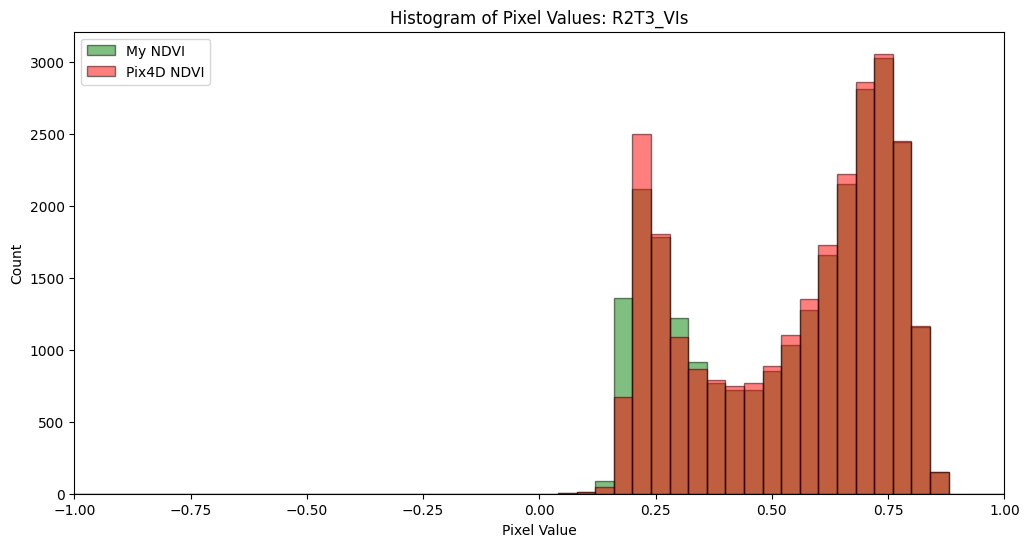

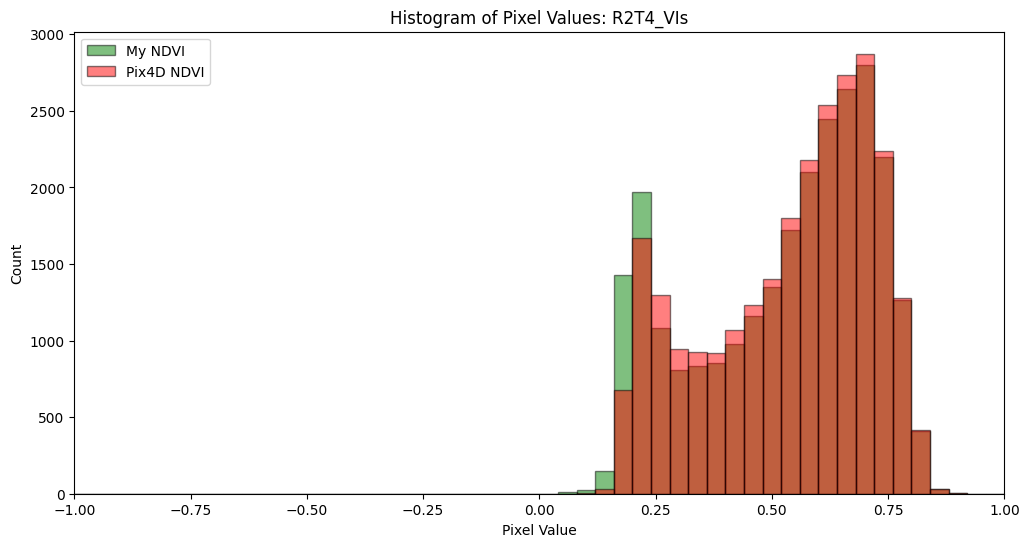

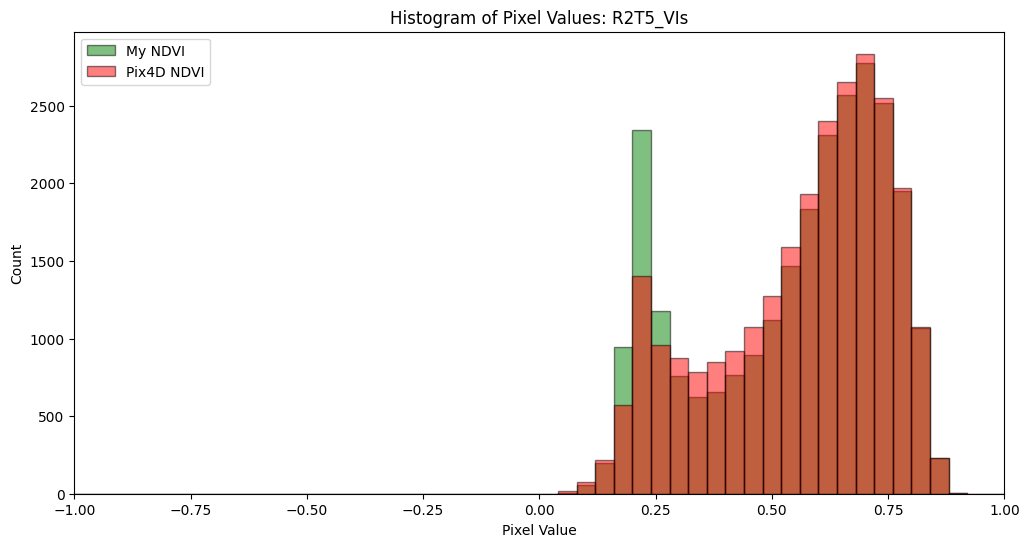

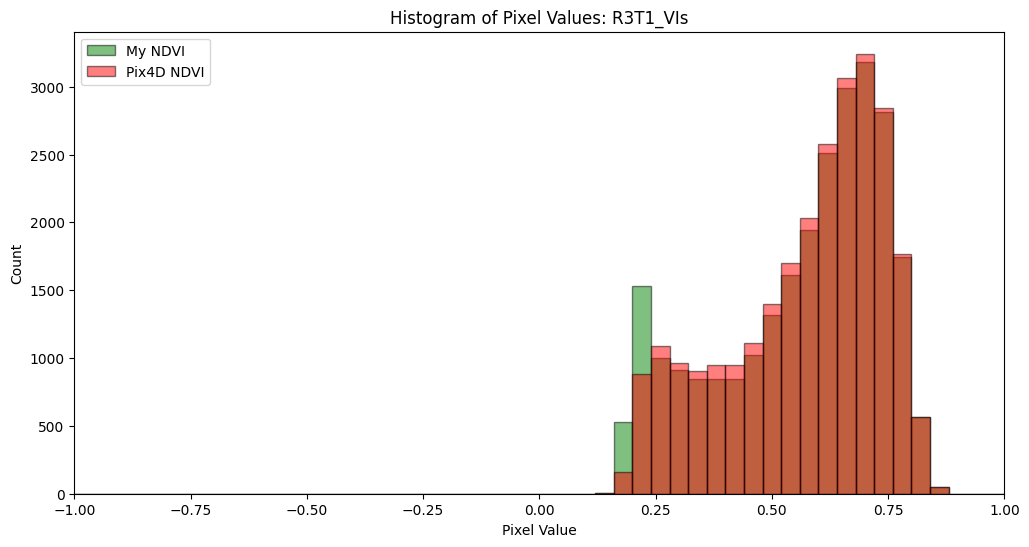

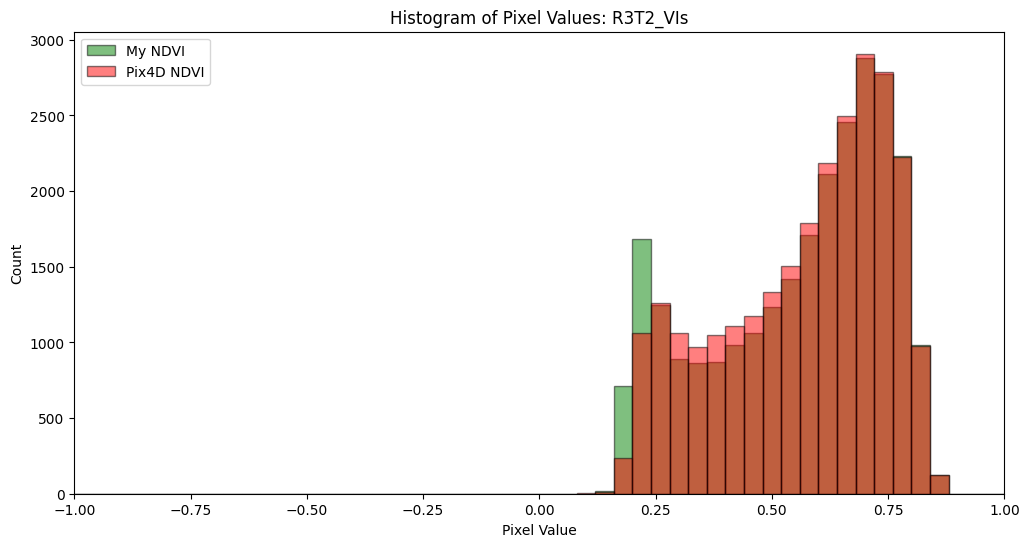

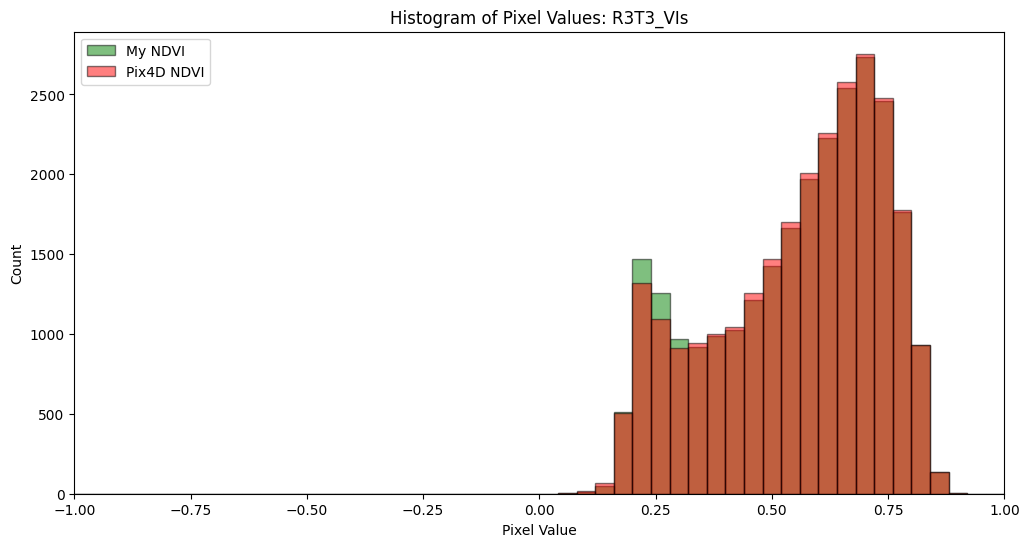

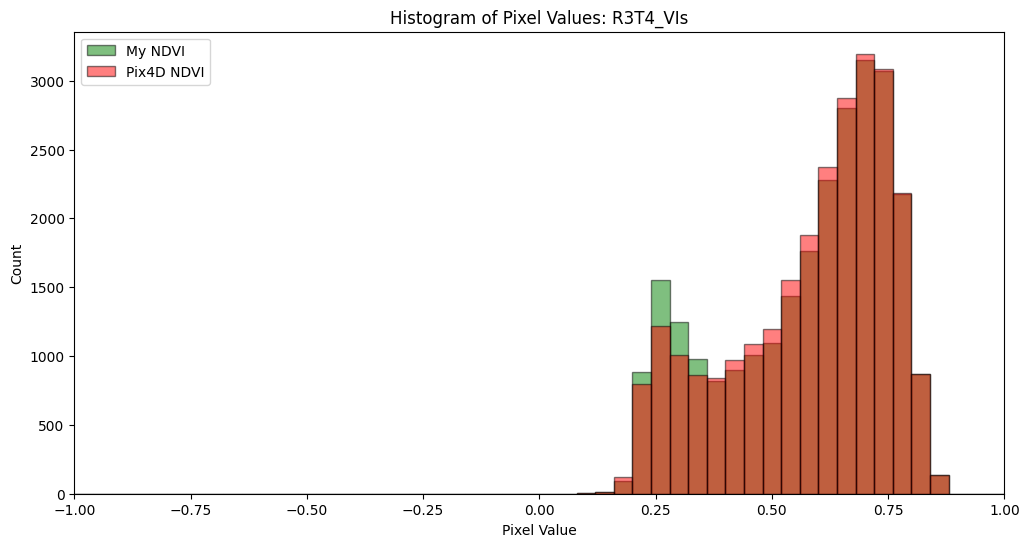

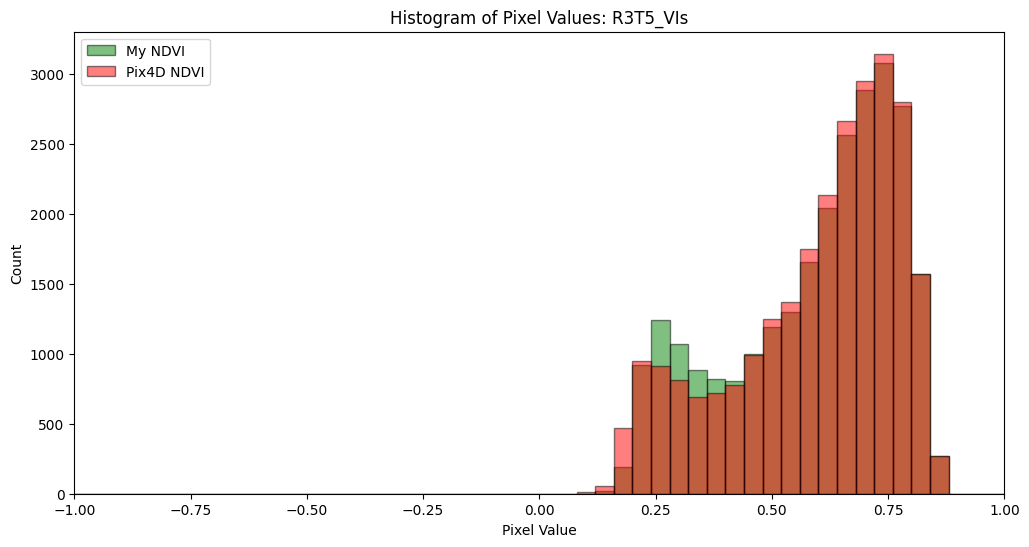

Total files with different shapes: 1


In [49]:
import os

pix4d_folder = '/raid/biplab/souravr/TIH/CROP/test_region_ndvi'
my_folder = '/raid/biplab/souravr/TIH/CROP/outputs/regions/28Aug23'
cnt = 0
for file in sorted(os.listdir(pix4d_folder)):
    if file.endswith('.tif'):
        pix4d_file_path = os.path.join(pix4d_folder, file)
        my_file_path = os.path.join(my_folder, file)

        pix4d_data, _, _, _ = utils.load_tif_numpy_with_meta(pix4d_file_path)
        my_data, _, _, _ = utils.load_tif_numpy_with_meta(my_file_path)

        pix4d_data = pix4d_data[0]  # Assuming NDVI is the first band
        my_data = my_data[0]  # Assuming NDVI is the first band
        
        if my_data.shape != pix4d_data.shape:
            new_rows = max(my_data.shape[0], pix4d_data.shape[0])
            new_cols = max(my_data.shape[1], pix4d_data.shape[1])
            
            padded_my_data = np.full((new_rows, new_cols), np.nan, dtype=my_data.dtype)
            padded_pix4d_data = np.full((new_rows, new_cols), np.nan, dtype=pix4d_data.dtype)
            
            padded_my_data[:my_data.shape[0], :my_data.shape[1]] = my_data
            padded_pix4d_data[:pix4d_data.shape[0], :pix4d_data.shape[1]] = pix4d_data
            
            my_data = padded_my_data
            pix4d_data = padded_pix4d_data
            cnt += 1

        pix4d_data[pix4d_data < -1] = np.nan
        my_data[my_data < -1] = np.nan
        # plot_residuals(residual, file.split('.')[0])
        # plot_heatmap(residual)
        plot_compare_hist(my_data, 'My NDVI', pix4d_data, 'Pix4D NDVI', file.split('.')[0])


print(f"Total files with different shapes: {cnt}")